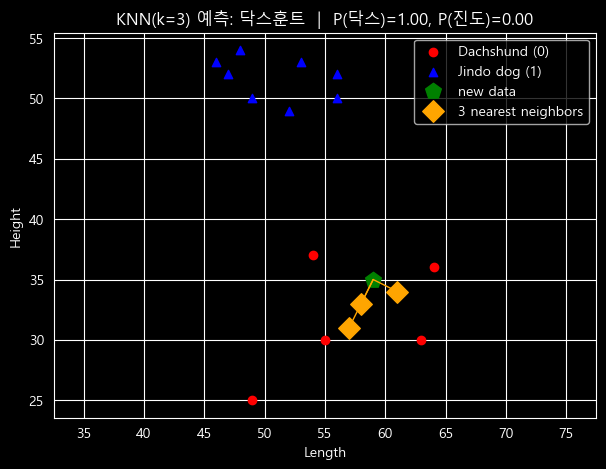

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier


plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕

# -----------------------------
# 1) 데이터 준비
# -----------------------------
# 닥스훈트(0)
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]

# 진돗개(1)
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]

# 새 데이터
newdata = np.array([[59, 35]])  # (1,2) 꼭 2차원!

# 학습용 X(dogs), y(labels) 만들기
d_data = np.column_stack((dach_length, dach_height))   # (8,2)
j_data = np.column_stack((jin_length, jin_height))     # (8,2)

dogs = np.vstack((d_data, j_data))                     # (16,2) 이거 뭐하는 함수야? 수직으로 묶어?
labels = np.hstack((np.zeros(len(d_data)), np.ones(len(j_data)))).astype(int)  # (16,)  가로로 묶어?

dog_classes = {0: '닥스훈트', 1: '진돗개'}

# -----------------------------
# 2) KNN 학습/예측
# -----------------------------
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(dogs, labels)

y_pred = knn.predict(newdata)[0] #이거 뭐해주느거야?
y_prob = knn.predict_proba(newdata)[0]  # [P(class0), P(class1)] 이거 뭐해주느거야?

# 가장 가까운 k개 이웃의 인덱스/거리 얻기
distances, indices = knn.kneighbors(newdata, n_neighbors=k)
neighbor_idx = indices[0]          # (k,)
neighbor_pts = dogs[neighbor_idx]  # (k,2)

# -----------------------------
# 3) 시각화
# -----------------------------
plt.figure(figsize=(7, 5))

# 전체 데이터(닥스/진돗개)
plt.scatter(dach_length, dach_height, c='r', label='Dachshund (0)')
plt.scatter(jin_length, jin_height, c='b', marker='^', label='Jindo dog (1)')

# 새 데이터 (초록 오각형)
plt.scatter(newdata[0, 0], newdata[0, 1],
            s=140, marker='p', c='g', label='new data')

# 가까운 이웃 k개를 주황색으로 강조
plt.scatter(neighbor_pts[:, 0], neighbor_pts[:, 1],
            s=120, c='orange', marker='D', label=f'{k} nearest neighbors')

# (선택) 새 점과 이웃을 선으로 연결
for pt in neighbor_pts:
    plt.plot([newdata[0, 0], pt[0]], [newdata[0, 1], pt[1]], 'orange', linewidth=1)

plt.title(f"KNN(k={k}) 예측: {dog_classes[y_pred]}  |  P(닥스)={y_prob[0]:.2f}, P(진도)={y_prob[1]:.2f}")
plt.xlabel('Length')
plt.ylabel('Height')
plt.legend(loc='upper right')
plt.axis('equal')  # 보기 좋게 축 비율 맞추기(선택)

plt.show()

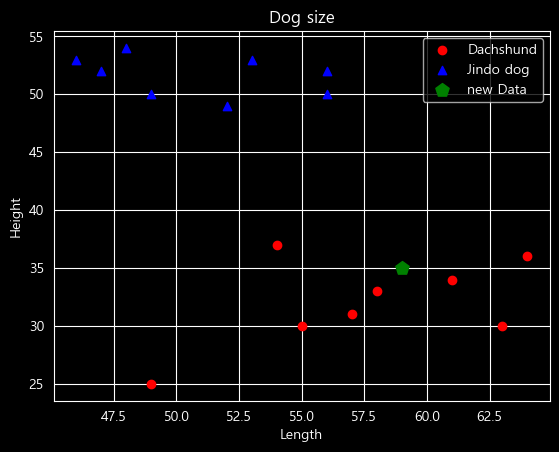

In [10]:
import matplotlib.pyplot as plt

# 닥스훈트의 길이와 높이 데이터
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]
# 진돗개의 길이와 높이 데이터
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]

newdata_length = [59]    # 새로운 데이터의 길이
newdata_height = [35]    # 새로운 데이터의 높이

plt.scatter(dach_length, dach_height, c='r', label='Dachshund')
plt.scatter(jin_length, jin_height,c='b',marker='^', label='Jindo dog')
# 새 데이터의 표식은 오각형(pentagon)으로 설정하고, 레이블은 new Data로
plt.scatter(newdata_length, newdata_height, s=100, marker='p', c='g', label='new Data')

plt.xlabel('Length')
plt.ylabel('Height')
plt.title("Dog size")
plt.legend(loc='upper right')

In [3]:
import numpy as np

d_data = np.column_stack((dach_length, dach_height))
d_label = np.zeros(len(d_data))   # 닥스훈트는 0으로 레이블링

j_data = np.column_stack((jin_length, jin_height))
j_label = np.ones(len(j_data))   # 진돗개는 1로 레이블링

In [4]:
import numpy as np

newdata = [[59, 35]]
dogs = np.concatenate((d_data, j_data))
labels = np.concatenate((d_label, j_label))
dog_classes = {0:'닥스훈트', 1:'진돗개'}

In [5]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

f = LogisticRegression()
f.fit(dogs, labels)
w = f.coef_[0] # 계수
b = f.intercept_[0] # 절편
print('계수:', w)
print('절편:', b)

print('분류 정확도:', f.score(dogs, labels))

y_pred = f.predict(newdata) #predict 함수는 배열 형태로 리턴
y_pred_prob = f.predict_proba(newdata) #predict_proba 함수는 배열 형태로 리턴
print(f'데이터: {newdata}')
print(f'판정 결과: {dog_classes[y_pred[0]]}, 판정 확률: {y_pred_prob}')

계수: [-0.12467735  0.60518946]
절편: -19.029836138332517
분류 정확도: 1.0
데이터: [[59, 35]]
판정 결과: 닥스훈트, 판정 확률: [[0.9945364 0.0054636]]


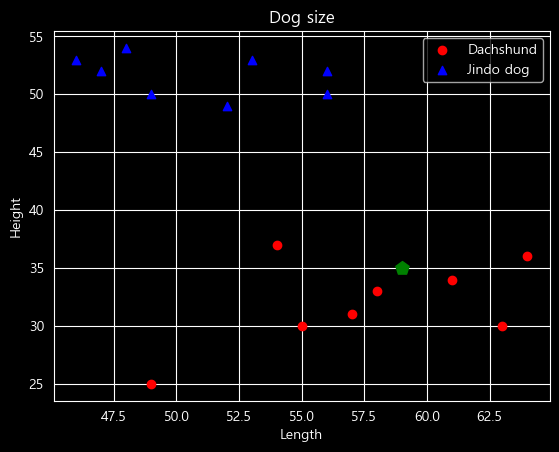

In [6]:
import matplotlib.pyplot as plt

# 닥스훈트의 길이와 높이 데이터
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]
# 진돗개의 길이와 높이 데이터
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]

newdata_length = [59]    # 새로운 데이터의 길이
newdata_height = [35]    # 새로운 데이터의 높이

plt.scatter(dach_length, dach_height, c='r', label='Dachshund')
plt.scatter(jin_length, jin_height,c='b',marker='^', label='Jindo dog')

plt.xlabel('Length')
plt.ylabel('Height')
plt.title("Dog size")
plt.legend(loc='upper right')

# 새 데이터의 표식은 오각형(pentagon)으로 설정하고, 레이블은 new Data로
plt.scatter(newdata_length, newdata_height, s=100, marker='p', c='g', label='new Data')
plt.show()

In [17]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import matplotlib.pyplot as plt
# 닥스훈트의 길이와 높이 데이터
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]
# 진돗개의 길이와 높이 데이터
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]
newdata = [[59, 35]]

d_data = np.column_stack((dach_length, dach_height))
d_label = np.zeros(len(d_data))   # 닥스훈트는 0으로 레이블링
j_data = np.column_stack((jin_length, jin_height))
j_label = np.ones(len(j_data))   # 진돗개는 1로 레이블링

dogs = np.concatenate((d_data, j_data))
labels = np.concatenate((d_label, j_label))

dog_classes = {0:'닥스훈트', 1:'진돗개'}

k = 3     # k를 3으로 두고 kNN 분류기를 만들어 보자
knn = KNeighborsClassifier(n_neighbors = k)


knn.fit(dogs, labels)
y_pred = knn.predict(newdata)
print('데이터', newdata, ', 판정 결과:', dog_classes[y_pred[0]])

데이터 [[59, 35]] , 판정 결과: 닥스훈트
